In [1]:
import os
import random
os.environ['PYTHONHASHSEED'] = '42'

import pandas as pd
import numpy as np
np.random.seed(42)
random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện tiền xử lý và mô hình
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Các thuật toán yêu cầu
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

import tensorflow as tf
tf.random.set_seed(42)

# Tắt cảnh báo để giao diện sạch sẽ
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Đọc dữ liệu (Đảm bảo bạn đã upload file lên Colab hoặc cùng thư mục)
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


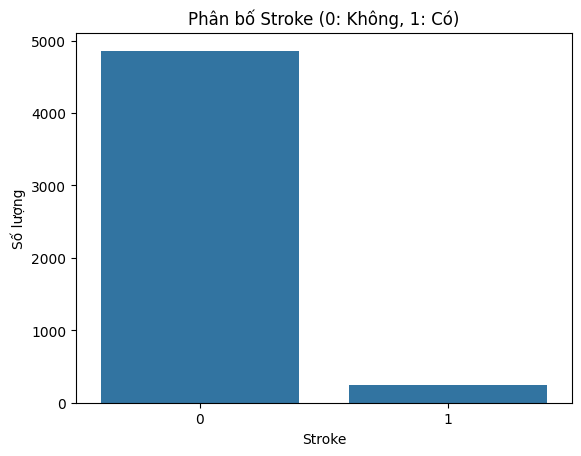

In [5]:
# Phân tích mất cân bằng
plt.figure()
sns.countplot(x='stroke', data=df)
plt.title("Phân bố Stroke (0: Không, 1: Có)")
plt.xlabel("Stroke")
plt.ylabel("Số lượng")
plt.show()

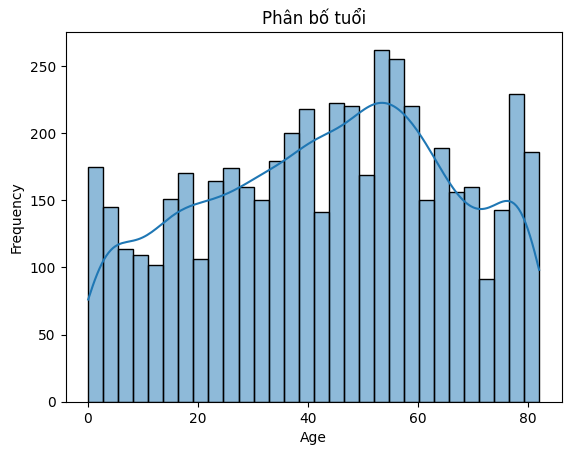

In [6]:
# Phân bố tuổi
plt.figure()
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Phân bố tuổi")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

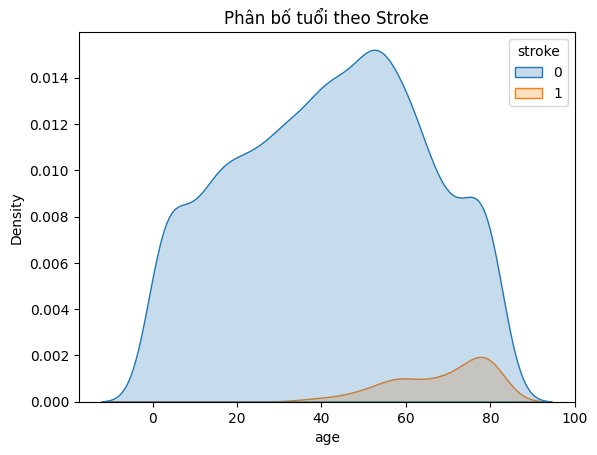

In [7]:
# Tuổi vs Stroke
plt.figure()
sns.kdeplot(data=df, x='age', hue='stroke', fill=True)
plt.title("Phân bố tuổi theo Stroke")
plt.show()

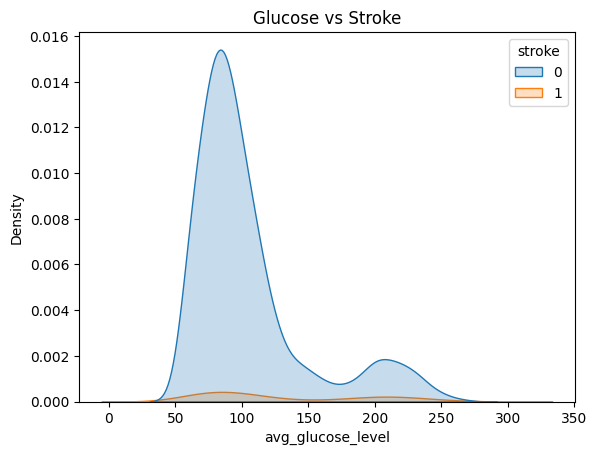

In [8]:
# Glucose vs Stroke 
plt.figure()
sns.kdeplot(data=df, x='avg_glucose_level', hue='stroke', fill=True)
plt.title("Glucose vs Stroke")
plt.show()

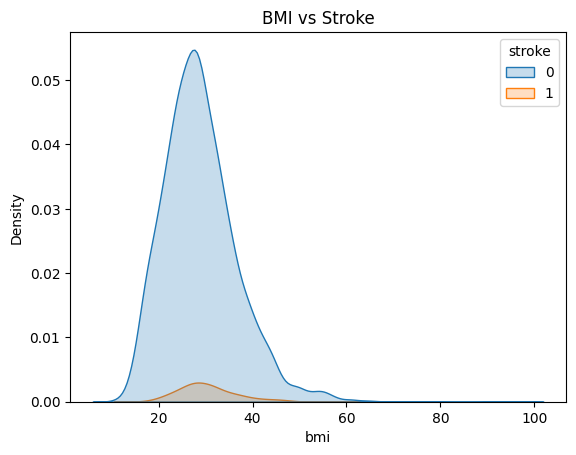

In [9]:
# BMI vs Stroke 
plt.figure()
sns.kdeplot(data=df, x='bmi', hue='stroke', fill=True)
plt.title("BMI vs Stroke")
plt.show()

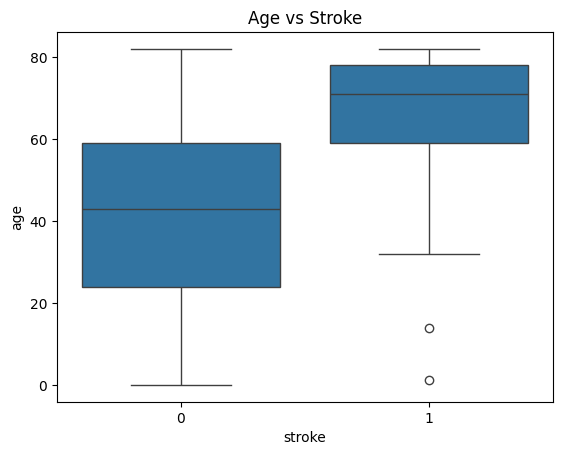

In [10]:
# Biểu đồ Boxplot (phát triển outlier)
plt.figure()
sns.boxplot(x='stroke', y='age', data=df)
plt.title("Age vs Stroke")
plt.show()

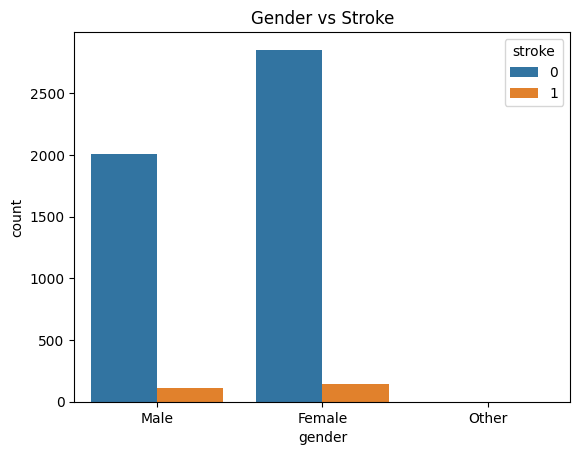

In [11]:
# Gender
plt.figure()
sns.countplot(x='gender', hue='stroke', data=df)
plt.title("Gender vs Stroke")
plt.show()

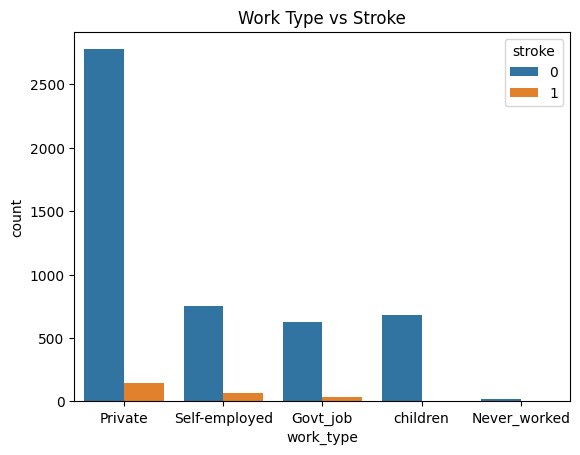

In [12]:
# Work type
plt.figure()
sns.countplot(x='work_type', hue='stroke', data=df)
plt.title("Work Type vs Stroke")
plt.show()

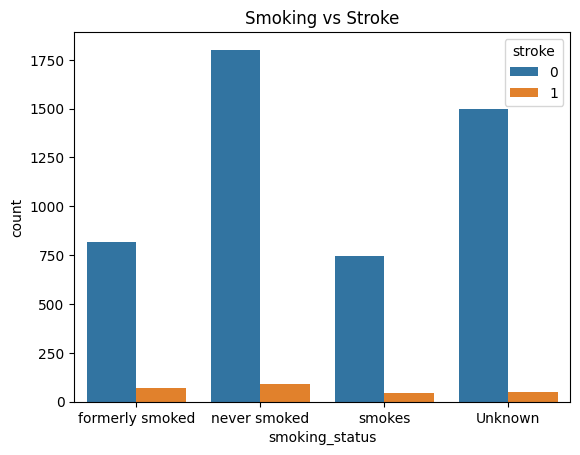

In [13]:
# Smoking status 
plt.figure()
sns.countplot(x='smoking_status', hue='stroke', data=df)
plt.title("Smoking vs Stroke")
plt.show()

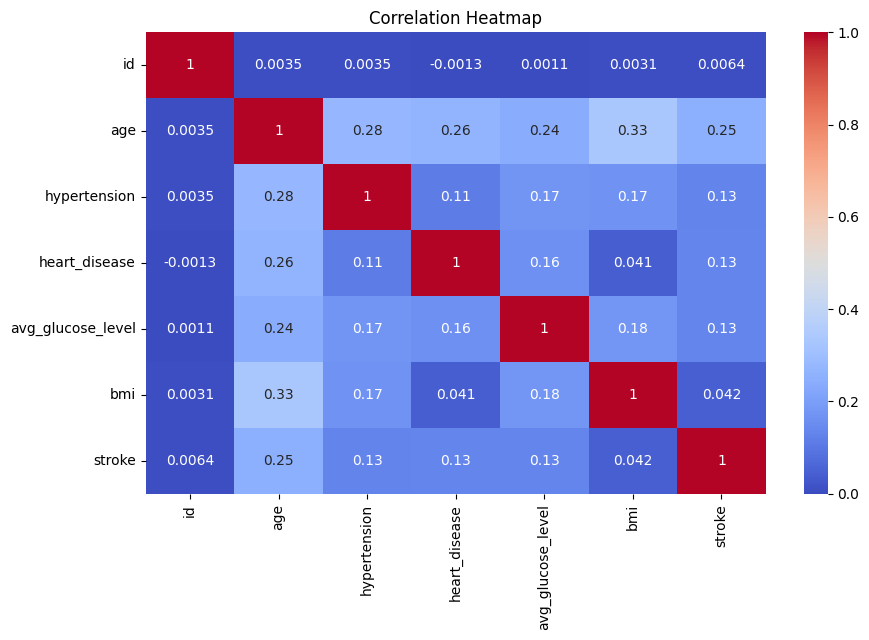

In [14]:
# Heatmap tương quan (quan trọng)
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

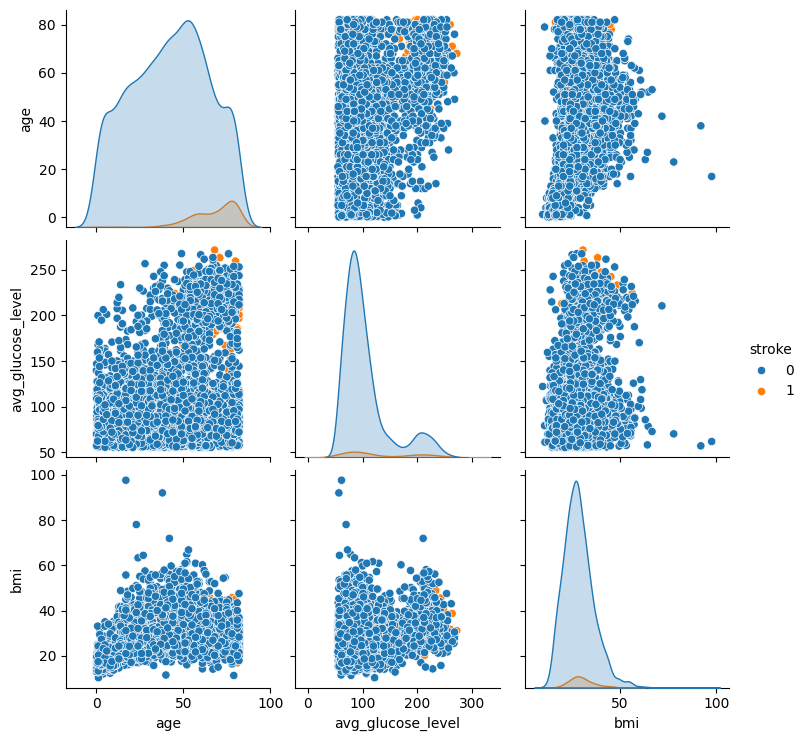

In [15]:
# Pairplot (nâng cao)
sns.pairplot(df[['age', 'avg_glucose_level', 'bmi', 'stroke']], hue='stroke')
plt.show()

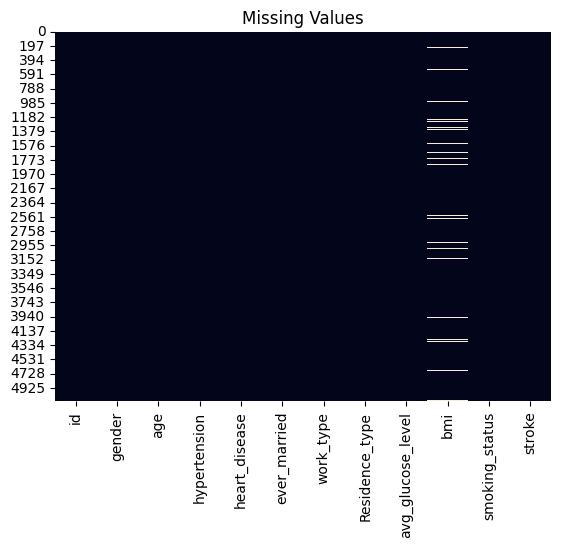

In [16]:
# Missing value (quan trọng)
plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

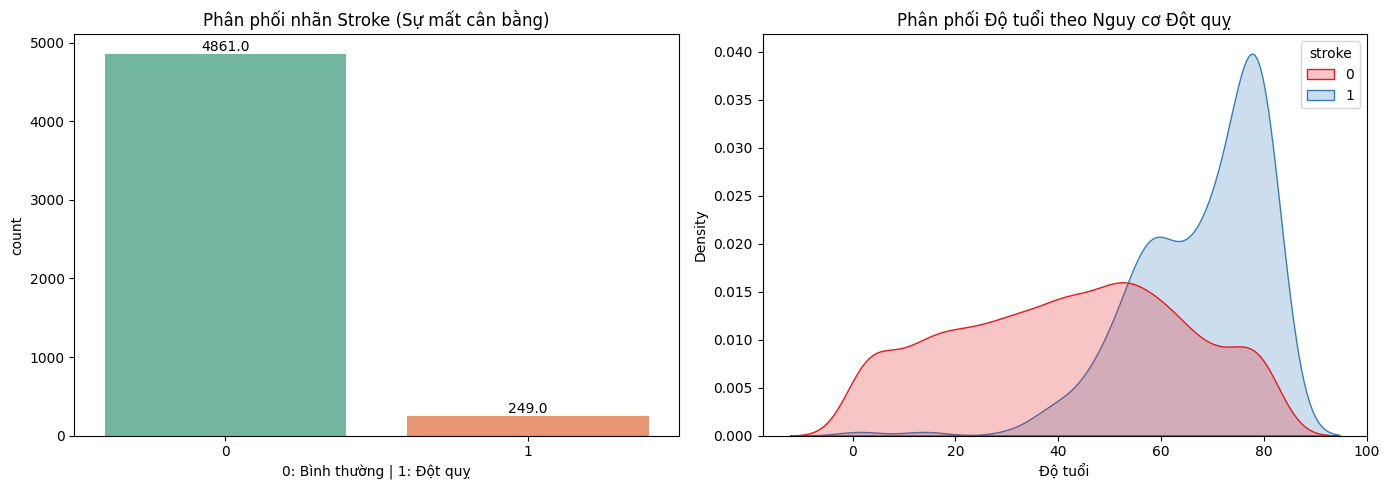

In [17]:
# Cell mới: Trực quan hóa dữ liệu (EDA)
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Sự mất cân bằng dữ liệu 
plt.subplot(1, 2, 1)
ax = sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Phân phối nhãn Stroke (Sự mất cân bằng)')
plt.xlabel('0: Bình thường | 1: Đột quỵ')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)
    
# Biểu đồ 2: Mối liên hệ giữa Tuổi và Nguy cơ đột quỵ
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='age', hue='stroke', fill=True, common_norm=False, palette='Set1')
plt.title('Phân phối Độ tuổi theo Nguy cơ Đột quỵ')
plt.xlabel('Độ tuổi')

plt.tight_layout()
plt.show()

In [18]:
# Kiểm ta các hàng trùng lặp 
print(df.duplicated().sum()) # Kiểm tra số lượng dòng trùng lặp
df[df.duplicated() == True] # Xem những dòng bị trùng đó là dòng nào
df = df.drop_duplicates() # Giữ lại một dòng duy nhất và xóa bỏ bản sao
print(df.duplicated().sum()) # Kiểm tra lại số lượng dòng trùng lặp sau khi đã xóa bỏ

0
0


In [19]:
# Xác định kiểu dữ liệu cột 
cat_col = [col for col in df.columns if df[col].dtype == 'string']
num_col = [col for col in df.columns if df[col].dtype != 'string']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Numerical columns: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


In [20]:
# Đếm số lượng giá trị duy nhất trong các cột phân loại 
print(df[cat_col].nunique())
# Liệt kê các giá trị khách nhau
for col in cat_col:
    print(f"Giá trị duy nhất trong cột {col}:")
    print(df[col].unique())
    print("-" * 20)


gender            3
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64
Giá trị duy nhất trong cột gender:
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
--------------------
Giá trị duy nhất trong cột ever_married:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------
Giá trị duy nhất trong cột work_type:
<StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
--------------------
Giá trị duy nhất trong cột Residence_type:
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
--------------------
Giá trị duy nhất trong cột smoking_status:
<StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str
--------------------


In [21]:
# Tính toán các giá trị thiếu dưới dạng phần trăm
round((df.isnull().sum() / df.shape[0]) * 100, 2)

id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64

In [22]:
# 1. Xử lý giá trị thiếu cho BMI
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [23]:
# Kiểm tra kết quả các giá trị thiếu dưới dạng phần trăm sau khi xử lý giá trị thiếu cho BMI
round((df.isnull().sum() / df.shape[0]) * 100, 2)

id                   0.0
gender               0.0
age                  0.0
hypertension         0.0
heart_disease        0.0
ever_married         0.0
work_type            0.0
Residence_type       0.0
avg_glucose_level    0.0
bmi                  0.0
smoking_status       0.0
stroke               0.0
dtype: float64

In [24]:
# 2. Loại bỏ cột ID
df.drop(['id'], axis=1, inplace=True)

In [25]:
# 3. Mã hóa biến phân loại (Categorical to Numerical)
# Chuyển đổi các cột chữ thành các cột số 0 và 1
df = pd.get_dummies(df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

In [26]:
# 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5110 non-null   float64
 1   hypertension                    5110 non-null   int64  
 2   heart_disease                   5110 non-null   int64  
 3   avg_glucose_level               5110 non-null   float64
 4   bmi                             5110 non-null   float64
 5   stroke                          5110 non-null   int64  
 6   gender_Male                     5110 non-null   bool   
 7   gender_Other                    5110 non-null   bool   
 8   ever_married_Yes                5110 non-null   bool   
 9   work_type_Never_worked          5110 non-null   bool   
 10  work_type_Private               5110 non-null   bool   
 11  work_type_Self-employed         5110 non-null   bool   
 12  work_type_children              5110 non-null

In [27]:
# 4. Tách đặc trưng (X) và nhãn (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

In [28]:
# 5. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

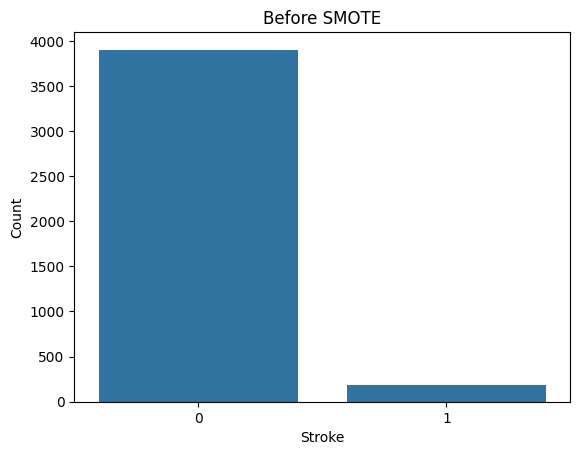

In [29]:
# Trước SMOTE 
plt.figure()
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [30]:
# 6. Xử lý mất cân bằng bằng SMOTE (Tạo thêm dữ liệu cho nhóm thiểu số)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [31]:
print(f"Kích thước tập huấn luyện sau khi SMOTE: {X_train_res.shape}")

Kích thước tập huấn luyện sau khi SMOTE: (7802, 16)


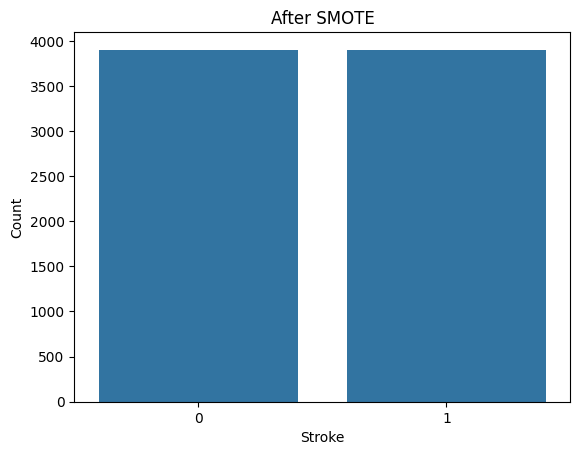

In [32]:
# Sau SMOTE 
plt.figure()
sns.countplot(x=y_train_res)
plt.title("After SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [33]:
# 7. Chuẩn hóa dữ liệu (Bắt buộc cho SVM và Neural Network)
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [34]:
# Tìm đặc trưng
def fitness_function(individual, X_tr, y_tr, X_te, y_te):
    selected = [i for i, bit in enumerate(individual) if bit == 1]
    if len(selected) == 0: return 0
    # Dùng Decision Tree để đánh giá nhanh "độ tốt" của bộ đặc trưng
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_tr[:, selected], y_tr)
    return f1_score(y_te, model.predict(X_te[:, selected]))

def run_ga(X_tr, y_tr, X_te, y_te, n_features):
    # Thiết lập seed trước GA để đảm bảo kết quả không thay đổi
    np.random.seed(42)
    
    pop_size = 15
    generations = 10
    # Khởi tạo quần thể ngẫu nhiên
    population = np.random.randint(0, 2, (pop_size, n_features))
    
    for g in range(generations):
        scores = [fitness_function(ind, X_tr, y_tr, X_te, y_te) for ind in population]
        # Chọn lọc các cá thể tốt nhất
        best_indices = np.argsort(scores)[-pop_size//2:]
        parents = population[best_indices]
        
        # Tạo thế hệ mới qua lai ghép
        offspring = []
        for i in range(pop_size - len(parents)):
            p1, p2 = parents[np.random.randint(0, len(parents), 2)]
            child = np.where(np.random.rand(n_features) > 0.5, p1, p2)
            offspring.append(child)
        
        population = np.vstack([parents, offspring])
        print(f"Gen {g+1}: Best F1 = {max(scores):.4f}")
    
    return population[np.argmax(scores)]

# Chạy GA để chọn đặc trưng
best_mask = run_ga(X_train_res, y_train_res, X_test, y_test, X_train_res.shape[1])
selected_features_idx = [i for i, bit in enumerate(best_mask) if bit == 1]
print(f"Số lượng đặc trưng tối ưu được chọn: {len(selected_features_idx)}")

Gen 1: Best F1 = 0.2939
Gen 2: Best F1 = 0.3071
Gen 3: Best F1 = 0.3071
Gen 4: Best F1 = 0.3071
Gen 5: Best F1 = 0.3071
Gen 6: Best F1 = 0.3071
Gen 7: Best F1 = 0.3077
Gen 8: Best F1 = 0.3077
Gen 9: Best F1 = 0.3077
Gen 10: Best F1 = 0.3077
Số lượng đặc trưng tối ưu được chọn: 3


In [35]:
# 1. Lấy danh sách tên đặc trưng
selected_feature_names = [X.columns[i] for i in selected_features_idx]

# 2. In ra kết quả
print("Các đặc trưng được chọn:")
print(selected_feature_names)

Các đặc trưng được chọn:
['age', 'smoking_status_formerly smoked', 'smoking_status_smokes']


In [36]:
# Lọc lại dữ liệu theo GA
X_train_ga = X_train_res[:, selected_features_idx]
X_test_ga = X_test[:, selected_features_idx]

In [37]:
#Huấn luyện
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_ga, y_train_res)
    y_pred = model.predict(X_test_ga)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       960
           1       0.15      0.85      0.26        62

    accuracy                           0.70      1022
   macro avg       0.57      0.77      0.53      1022
weighted avg       0.94      0.70      0.78      1022


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       960
           1       0.21      0.74      0.32        62

    accuracy                           0.81      1022
   macro avg       0.59      0.78      0.61      1022
weighted avg       0.93      0.81      0.86      1022


--- SVM ---
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       960
           1       0.16      0.82      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg     

In [38]:
# Thiết lập seed trước Neural Network để đảm bảo reproducible
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(len(selected_features_idx),)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Phân loại nhị phân
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

# Huấn luyện
history = nn_model.fit(X_train_ga, y_train_res, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

# Dự đoán
nn_preds = (nn_model.predict(X_test_ga) > 0.5).astype(int)
print("\n--- Neural Network ---")
print(classification_report(y_test, nn_preds))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Neural Network ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       960
           1       0.20      0.69      0.30        62

    accuracy                           0.81      1022
   macro avg       0.59      0.75      0.60      1022
weighted avg       0.93      0.81      0.85      1022



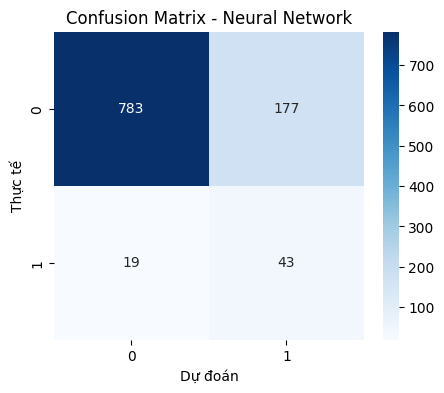

In [39]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, nn_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()